# Question Clustering - Training Pipeline

Splits the benchmark into train/test, clusters the **training** questions using sentence
embeddings and KMeans, determines the optimal resolution per cluster, and outputs the
trained model + resolution mapping + the split assignment.

The held-out test set is never touched here — it is evaluated in
`clustering/inference/clustering_inference.ipynb`.

In [1]:
# Setup: Determine project root
from pathlib import Path
import sys

# Find project root (contains pyproject.toml)
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "pyproject.toml").exists():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise RuntimeError("Could not find project root (pyproject.toml)")
    PROJECT_ROOT = PROJECT_ROOT.parent

print(f"Project root: {PROJECT_ROOT}")
sys.path.insert(0, str(PROJECT_ROOT))

Project root: C:\Users\Andrew\Msc\scale-wise-optimizer


In [2]:
import json
import re
import os
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import friedmanchisquare
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sentence_transformers import SentenceTransformer

sns.set_style("whitegrid")
%matplotlib inline

C:\Users\Andrew\Msc\scale-wise-optimizer\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# =============================================================================
# CONFIGURATION
# =============================================================================

# Dataset paths
DATASET = str(PROJECT_ROOT / 'benchmarks/seedbench_2_plus/test_questions.jsonl')
SCORES_FILE = str(PROJECT_ROOT / 'benchmarks/seedbench_2_plus/seedbench_2_plus_resolution_analysis.xlsx')
SCORES_SHEET = 'Consolidated_Scores'

# Train/test split
TEST_SIZE = 0.20          # fraction held out; never seen during fitting
STRATIFY_BY = 'subject'   # keeps the Chart/Map/Web mix identical in both halves

# Clustering parameters
MIN_K = 5
MAX_K = 30
RANDOM_STATE = 42

# Resolutions to analyze
RESOLUTIONS = ['2000', '12500', '25000', '50000', '100000', '150000', '250000', '400000', '600000', '800000']

# Embedding model
EMBEDDING_MODEL = 'all-MiniLM-L6-v2'

# Output paths
MODEL_OUTPUT = str(PROJECT_ROOT / 'clustering/training/artifacts/clustering_model.pkl')
MAPPING_OUTPUT = str(PROJECT_ROOT / 'clustering/training/results/cluster_resolution_mapping.csv')
SPLIT_OUTPUT = str(PROJECT_ROOT / 'clustering/training/results/data_split.csv')

## 1. Data Loading & Preprocessing

In [4]:
# Load questions
questions = []
with open(DATASET, 'r', encoding='utf-8') as f:
    for line in f:
        questions.append(json.loads(line))
df = pd.DataFrame(questions)

# Load resolution scores
df_scores = pd.read_excel(SCORES_FILE, sheet_name=SCORES_SHEET)
df = df.merge(df_scores[['doc_id'] + RESOLUTIONS], on='doc_id', how='left')

# Clean text: remove instruction and options
def clean_input(text):
    text = text.replace("Answer with the option's letter from the given choices directly.", "").strip()
    match = re.search(r'\n[A-D]\.\s', text)
    return text[:match.start()].strip() if match else text

df['question_stem'] = df['input'].apply(clean_input)

# Benchmark subject (Chart / Map / Web) — one sub-task key is present per row
subject_cols = [c for c in df.columns
                if c.startswith('seedbench_2_plus_') and c != 'seedbench_2_plus_all']
df['subject'] = (df[subject_cols].notna().idxmax(axis=1)
                 .str.replace('seedbench_2_plus_', '', regex=False))

print(f"Loaded {len(df)} questions with {len(RESOLUTIONS)} resolutions")
print(df['subject'].value_counts().to_string())

Loaded 2277 questions with 10 resolutions
subject
Chart    810
Map      807
Web      660


## 1.1 Train/test split

The cluster→resolution mapping is fitted on the training half only. The test half is
written to `data_split.csv` and consumed by the inference notebook, so the reported
test numbers are a genuine out-of-sample estimate.

In [5]:
# Hold out a stratified test set — fitted artefacts must never see these rows
df_train, df_test = train_test_split(
    df,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    shuffle=True,
    stratify=df[STRATIFY_BY],
)
df_train = df_train.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

# Persist the assignment so inference evaluates exactly these held-out rows
os.makedirs(os.path.dirname(SPLIT_OUTPUT), exist_ok=True)
df_split = pd.concat([
    pd.DataFrame({'doc_id': df_train['doc_id'], 'split': 'train'}),
    pd.DataFrame({'doc_id': df_test['doc_id'], 'split': 'test'}),
]).sort_values('doc_id').reset_index(drop=True)
df_split.to_csv(SPLIT_OUTPUT, index=False)

print(f"Train: {len(df_train)} questions  ·  Test: {len(df_test)} questions "
      f"({TEST_SIZE:.0%} held out, stratified by {STRATIFY_BY})")
print(f"Split assignment saved to {SPLIT_OUTPUT}\n")
print(pd.crosstab(df_split['split'], df.set_index('doc_id').loc[df_split['doc_id'], 'subject'].values))

# From here on, only df_train is used.
del df_test

Train: 1821 questions  ·  Test: 456 questions (20% held out, stratified by subject)
Split assignment saved to C:\Users\Andrew\Msc\scale-wise-optimizer\clustering\training\results\data_split.csv



col_0  Chart  Map  Web
split                 
test     162  162  132
train    648  645  528


## 2. Clustering

In [6]:
print("Loading sentence transformer model...")
model = SentenceTransformer(EMBEDDING_MODEL)

print("Generating embeddings (training set only)...")
embeddings = model.encode(df_train['question_stem'].tolist(), show_progress_bar=True)
print(f"Embeddings shape: {embeddings.shape}")

Loading sentence transformer model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   1%|          | 1/103 [00:00<00:00, 1956.30it/s, Materializing param=embeddings.LayerNorm.bias]

Loading weights:   1%|          | 1/103 [00:00<00:18,  5.47it/s, Materializing param=embeddings.LayerNorm.bias]  

Loading weights:   2%|▏         | 2/103 [00:00<00:19,  5.23it/s, Materializing param=embeddings.LayerNorm.bias]

...

Batches:  96%|█████████▋| 55/57 [00:36<00:00,  2.15it/s]

Batches:  98%|█████████▊| 56/57 [00:36<00:00,  2.24it/s]

Batches: 100%|██████████| 57/57 [00:37<00:00,  2.32it/s]

Batches: 100%|██████████| 57/57 [00:37<00:00,  1.54it/s]

Embeddings shape: (1821, 384)


Finding optimal K...


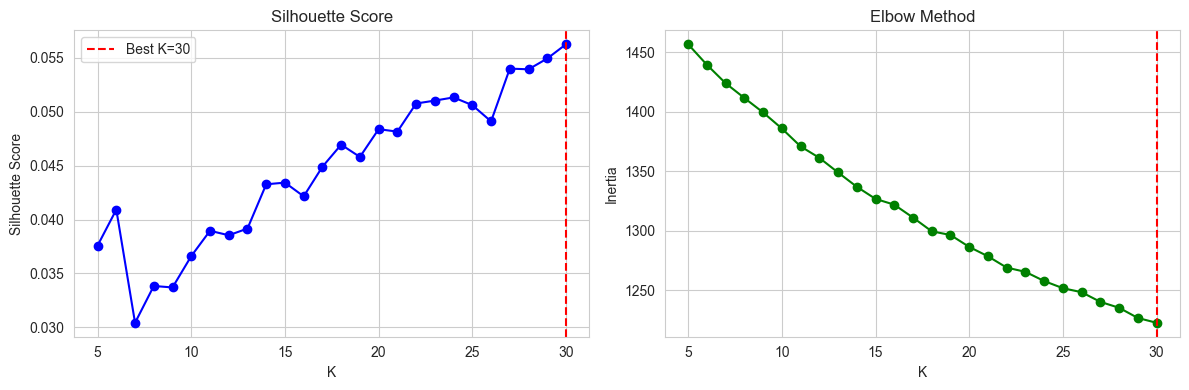


Optimal K: 30


In [7]:
# K Selection
k_range = range(MIN_K, MAX_K + 1)
silhouette_scores = []
inertias = []

print("Finding optimal K...")
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = kmeans.fit_predict(embeddings)
    silhouette_scores.append(silhouette_score(embeddings, labels))
    inertias.append(kmeans.inertia_)

OPTIMAL_K = k_range[np.argmax(silhouette_scores)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(k_range, silhouette_scores, 'bo-')
ax1.axvline(OPTIMAL_K, color='red', linestyle='--', label=f'Best K={OPTIMAL_K}')
ax1.set_xlabel('K'); ax1.set_ylabel('Silhouette Score'); ax1.set_title('Silhouette Score'); ax1.legend()

ax2.plot(k_range, inertias, 'go-')
ax2.axvline(OPTIMAL_K, color='red', linestyle='--')
ax2.set_xlabel('K'); ax2.set_ylabel('Inertia'); ax2.set_title('Elbow Method')

plt.tight_layout()
plt.show()
print(f"\nOptimal K: {OPTIMAL_K}")

In [8]:
# Train final model and save
kmeans_final = KMeans(n_clusters=OPTIMAL_K, random_state=RANDOM_STATE, n_init=10)
df_train['cluster'] = kmeans_final.fit_predict(embeddings)

# Save model
os.makedirs(os.path.dirname(MODEL_OUTPUT), exist_ok=True)
with open(MODEL_OUTPUT, 'wb') as f:
    pickle.dump({'kmeans': kmeans_final, 'embedding_model': EMBEDDING_MODEL, 'optimal_k': OPTIMAL_K}, f)

print(f"Model saved to {MODEL_OUTPUT}")
print(f"\nCluster distribution (training set):")
print(df_train['cluster'].value_counts().sort_index())

Model saved to C:\Users\Andrew\Msc\scale-wise-optimizer\clustering\training\artifacts\clustering_model.pkl

Cluster distribution (training set):
cluster
0      15
1     107
2      34
3      63
4     110
5      56
6     102
7      35
8      72
9      51
10     51
11     50
12     37
13     26
14    131
15     94
16     47
17     44
18     34
19    106
20     21
21     52
22    127
23     55
24     71
25     41
26     31
27     27
28     53
29     78
Name: count, dtype: int64


Running t-SNE...


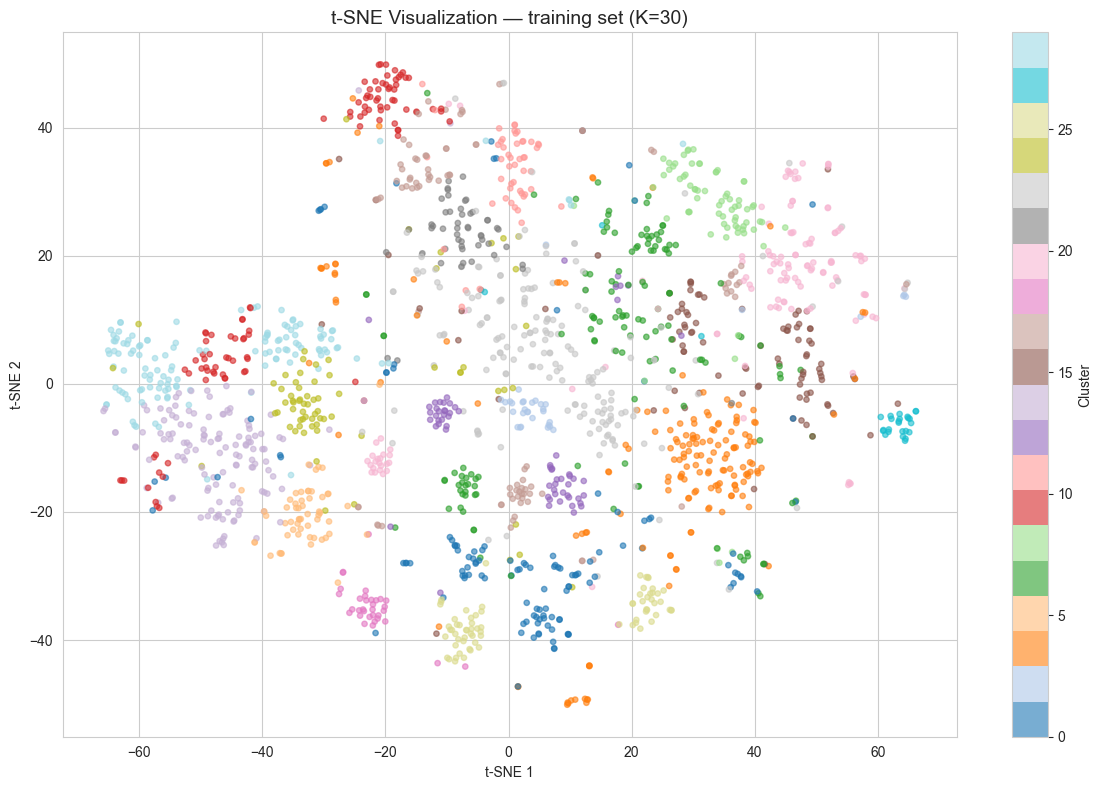

In [9]:
# t-SNE Visualization
print("Running t-SNE...")
tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30, init='pca', learning_rate='auto')
tsne_coords = tsne.fit_transform(embeddings)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(tsne_coords[:, 0], tsne_coords[:, 1], c=df_train['cluster'], cmap='tab20', alpha=0.6, s=15)
plt.colorbar(scatter, label='Cluster')
plt.title(f't-SNE Visualization — training set (K={OPTIMAL_K})', fontsize=14)
plt.xlabel('t-SNE 1'); plt.ylabel('t-SNE 2')
plt.tight_layout()
plt.show()

## 3. Resolution Analysis

In [10]:
# Compute accuracy per cluster per resolution (training set)
cluster_perf = []
for cluster_id in sorted(df_train['cluster'].unique()):
    subset = df_train[df_train['cluster'] == cluster_id]
    row = {'cluster': cluster_id, 'n_questions': len(subset)}
    for res in RESOLUTIONS:
        row[f'acc_{res}'] = subset[res].mean()
    cluster_perf.append(row)

df_cluster = pd.DataFrame(cluster_perf).set_index('cluster')

# Compute summary stats
acc_cols = [f'acc_{r}' for r in RESOLUTIONS]
df_cluster['mean_acc'] = df_cluster[acc_cols].mean(axis=1)
df_cluster['std_acc'] = df_cluster[acc_cols].std(axis=1)
df_cluster['min_acc'] = df_cluster[acc_cols].min(axis=1)
df_cluster['max_acc'] = df_cluster[acc_cols].max(axis=1)
df_cluster['range_acc'] = df_cluster['max_acc'] - df_cluster['min_acc']
df_cluster['best_resolution'] = df_cluster[acc_cols].idxmax(axis=1).str.replace('acc_', '')
df_cluster['worst_resolution'] = df_cluster[acc_cols].idxmin(axis=1).str.replace('acc_', '')

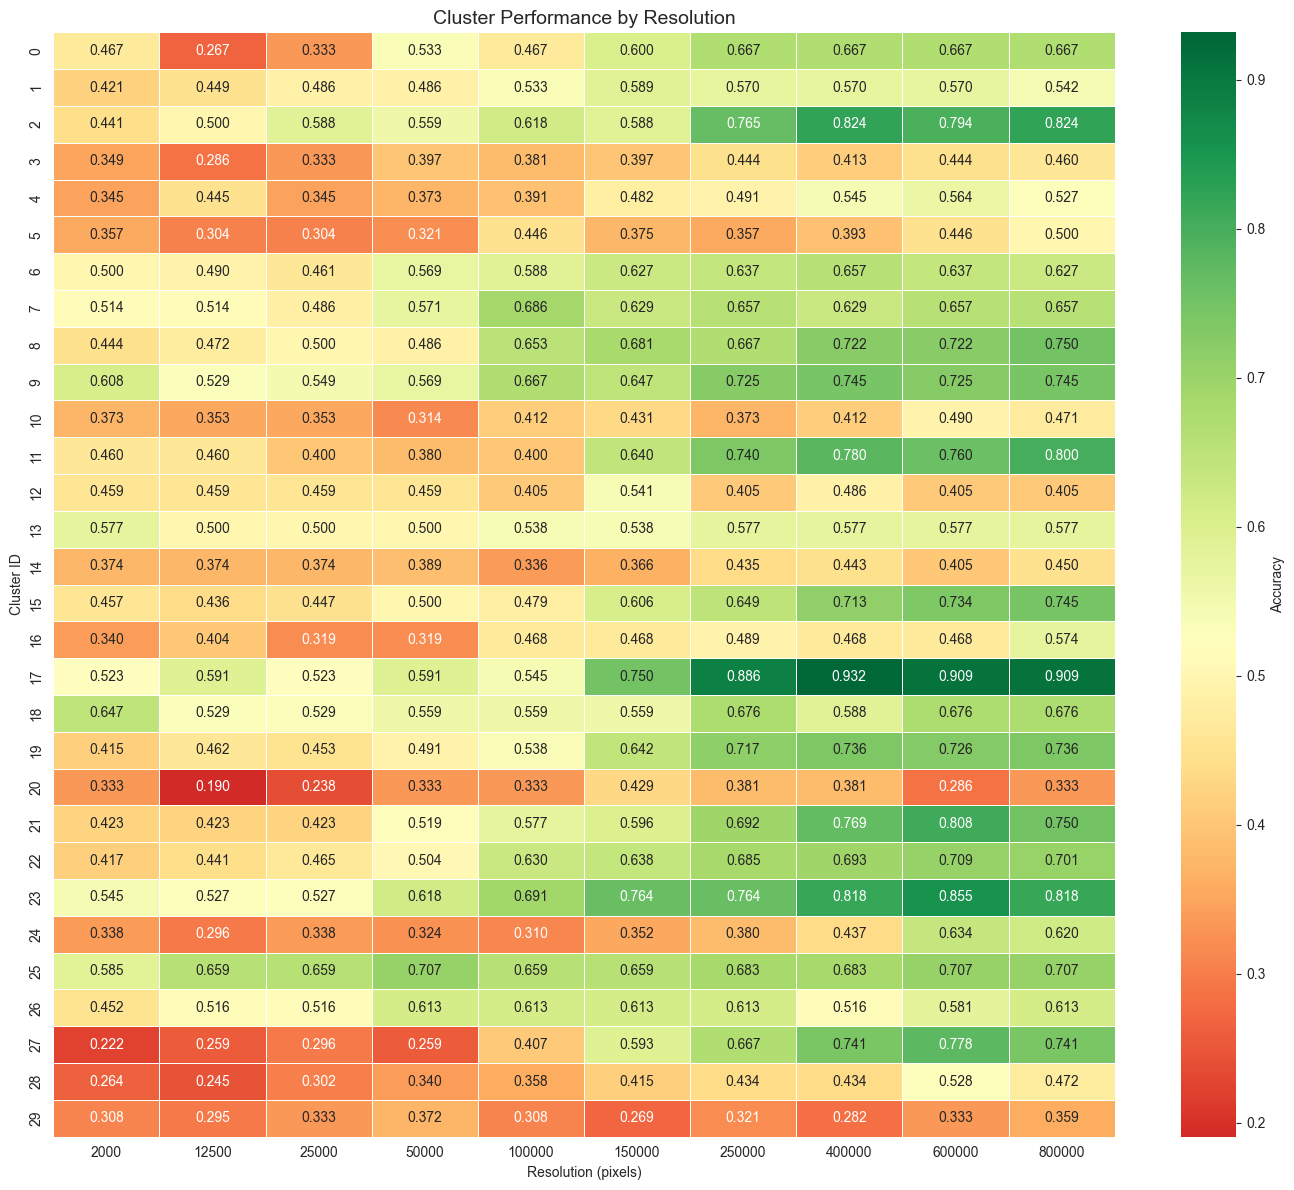

In [11]:
# Cluster Performance by Resolution - Heatmap
heatmap_data = df_cluster[acc_cols].copy()
heatmap_data.columns = RESOLUTIONS

plt.figure(figsize=(14, max(8, OPTIMAL_K * 0.4)))
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='RdYlGn', 
            center=heatmap_data.values.mean(), linewidths=0.5, cbar_kws={'label': 'Accuracy'})
plt.title('Cluster Performance by Resolution', fontsize=14)
plt.xlabel('Resolution (pixels)'); plt.ylabel('Cluster ID')
plt.tight_layout()
plt.show()

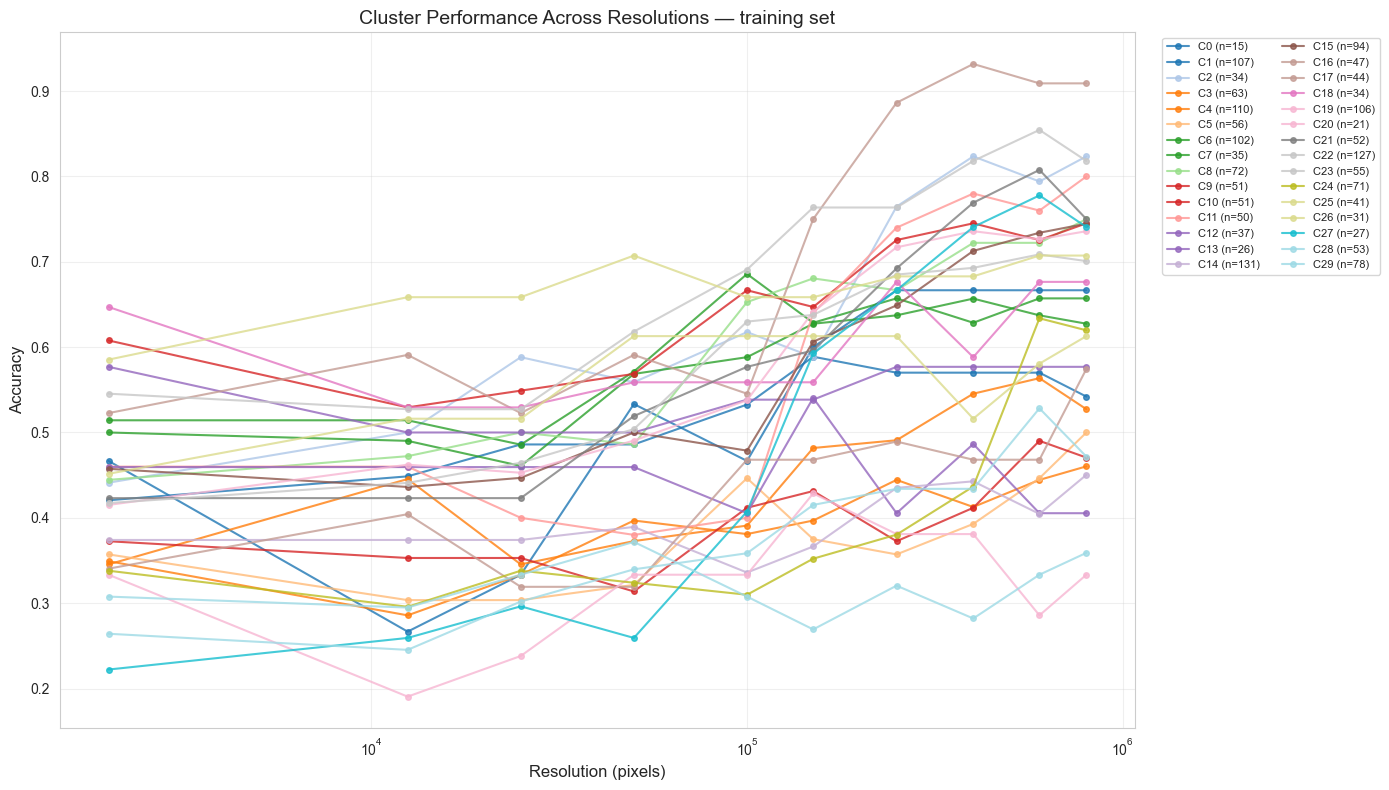

In [12]:
# Cluster Performance Across Resolutions - Line Plot
plt.figure(figsize=(14, 8))
resolutions_int = [int(r) for r in RESOLUTIONS]
colors = plt.cm.tab20(np.linspace(0, 1, OPTIMAL_K))

for cluster_id in sorted(df_train['cluster'].unique()):
    accuracies = [df_cluster.loc[cluster_id, f'acc_{r}'] for r in RESOLUTIONS]
    n = df_cluster.loc[cluster_id, 'n_questions']
    plt.plot(resolutions_int, accuracies, 'o-', color=colors[cluster_id],
             label=f'C{cluster_id} (n={n})', linewidth=1.5, markersize=4, alpha=0.8)

plt.xlabel('Resolution (pixels)', fontsize=12); plt.ylabel('Accuracy', fontsize=12)
plt.title('Cluster Performance Across Resolutions — training set', fontsize=14)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8, ncol=2)
plt.xscale('log'); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
# Cluster Resolution Sensitivity Analysis Table
sensitivity_table = df_cluster[['n_questions', 'mean_acc', 'std_acc', 'min_acc', 'max_acc', 
                                 'range_acc', 'best_resolution', 'worst_resolution']].copy()

print("=" * 100)
print("CLUSTER RESOLUTION SENSITIVITY ANALYSIS")
print("=" * 100)
display(sensitivity_table.round(4))

CLUSTER RESOLUTION SENSITIVITY ANALYSIS


,n_questions,mean_acc,std_acc,min_acc,max_acc,range_acc,best_resolution,worst_resolution
cluster,,,,,,,,
0,15,0.5333,0.1474,0.2667,0.6667,0.4000,250000,12500
1,107,0.5215,0.0579,0.4206,0.5888,0.1682,150000,2000
2,34,0.6500,0.1403,0.4412,0.8235,0.3824,400000,2000
3,63,0.3905,0.0551,0.2857,0.4603,0.1746,800000,12500
4,110,0.4509,0.0830,0.3455,0.5636,0.2182,600000,2000
5,56,0.3804,0.0663,0.3036,0.5000,0.1964,800000,12500
6,102,0.5794,0.0714,0.4608,0.6569,0.1961,400000,25000
7,35,0.6000,0.0725,0.4857,0.6857,0.2000,100000,25000
8,72,0.6097,0.1196,0.4444,0.7500,0.3056,800000,2000


## 4. Statistical Analysis

In [14]:
# Statistical Test Results by Cluster (Friedman Test)
stat_results = []
for cluster_id in sorted(df_train['cluster'].unique()):
    subset = df_train[df_train['cluster'] == cluster_id]
    scores = subset[RESOLUTIONS].values

    try:
        stat, p_val = friedmanchisquare(*[scores[:, i] for i in range(len(RESOLUTIONS))])
    except Exception:
        stat, p_val = np.nan, np.nan

    stat_results.append({
        'cluster': cluster_id,
        'n_questions': len(subset),
        'friedman_stat': stat,
        'p_value': p_val,
        'significant (p<0.05)': p_val < 0.05 if not np.isnan(p_val) else False,
        'best_resolution': df_cluster.loc[cluster_id, 'best_resolution'],
        'best_accuracy': df_cluster.loc[cluster_id, 'max_acc'],
        'range_acc': df_cluster.loc[cluster_id, 'range_acc']
    })

df_friedman = pd.DataFrame(stat_results).sort_values('cluster').reset_index(drop=True)

sig_count = df_friedman['significant (p<0.05)'].sum()
print("=" * 100)
print("STATISTICAL TEST RESULTS BY CLUSTER (Friedman Test, training set)")
print("=" * 100)
print(f"\nClusters where resolution significantly affects accuracy: {sig_count} / {OPTIMAL_K}")
print(f"Clusters where resolution does NOT significantly matter:  {OPTIMAL_K - sig_count} / {OPTIMAL_K}\n")
display(df_friedman.round(4))

STATISTICAL TEST RESULTS BY CLUSTER (Friedman Test, training set)

Clusters where resolution significantly affects accuracy: 18 / 30
Clusters where resolution does NOT significantly matter:  12 / 30



,cluster,n_questions,friedman_stat,p_value,significant (p<0.05),best_resolution,best_accuracy,range_acc
0,0,15,15.8400,0.0703,False,250000,0.6667,0.4000
1,1,107,29.6794,0.0005,True,150000,0.5888,0.1682
2,2,34,46.6861,0.0000,True,400000,0.8235,0.3824
3,3,63,15.4367,0.0796,False,800000,0.4603,0.1746
4,4,110,52.8451,0.0000,True,600000,0.5636,0.2182
5,5,56,18.9626,0.0255,True,800000,0.5000,0.1964
6,6,102,65.5282,0.0000,True,400000,0.6569,0.1961
7,7,35,12.0833,0.2087,False,100000,0.6857,0.2000
8,8,72,74.5602,0.0000,True,800000,0.7500,0.3056
9,9,51,26.9670,0.0014,True,400000,0.7451,0.2157


## 5. Resolution Recommendations

In [15]:
# Resolution Recommendations: best, 95pct, 99pct + save CSV
os.makedirs(os.path.dirname(MAPPING_OUTPUT), exist_ok=True)

recommendations = []
for cluster_id in sorted(df_train['cluster'].unique()):
    row = df_cluster.loc[cluster_id]
    acc_at_res = {res: row[f'acc_{res}'] for res in RESOLUTIONS}

    best_res = max(acc_at_res, key=acc_at_res.get)
    best_acc = acc_at_res[best_res]

    # Efficient (95%) — RESOLUTIONS is ascending, so the first hit is the cheapest
    threshold_95 = best_acc * 0.95
    eff_95 = best_res
    for res in RESOLUTIONS:
        if acc_at_res[res] >= threshold_95:
            eff_95 = res
            break

    # Efficient (99%)
    threshold_99 = best_acc * 0.99
    eff_99 = best_res
    for res in RESOLUTIONS:
        if acc_at_res[res] >= threshold_99:
            eff_99 = res
            break

    recommendations.append({
        'cluster': cluster_id,
        'n_questions': row['n_questions'],
        'best_resolution': best_res,
        'best_accuracy': best_acc,
        'efficient_res_95pct': eff_95,
        'acc_at_95pct': acc_at_res[eff_95],
        'efficient_res_99pct': eff_99,
        'acc_at_99pct': acc_at_res[eff_99],
    })

df_rec = pd.DataFrame(recommendations).sort_values('cluster').reset_index(drop=True)
df_rec.to_csv(MAPPING_OUTPUT, index=False)

print(f"Resolution mapping saved to {MAPPING_OUTPUT}")
print("=" * 110)
print("RESOLUTION RECOMMENDATIONS BY CLUSTER (fitted on training set)")
print("=" * 110)
print("\n- best_resolution:      Resolution with highest accuracy")
print("- efficient_res_95pct:  Lowest resolution achieving >= 95% of best accuracy")
print("- efficient_res_99pct:  Lowest resolution achieving >= 99% of best accuracy\n")
display(df_rec.round(4))

Resolution mapping saved to C:\Users\Andrew\Msc\scale-wise-optimizer\clustering\training\results\cluster_resolution_mapping.csv
RESOLUTION RECOMMENDATIONS BY CLUSTER (fitted on training set)

- best_resolution:      Resolution with highest accuracy
- efficient_res_95pct:  Lowest resolution achieving >= 95% of best accuracy
- efficient_res_99pct:  Lowest resolution achieving >= 99% of best accuracy



,cluster,n_questions,best_resolution,best_accuracy,efficient_res_95pct,acc_at_95pct,efficient_res_99pct,acc_at_99pct
0,0,15,250000,0.6667,250000,0.6667,250000,0.6667
1,1,107,150000,0.5888,150000,0.5888,150000,0.5888
2,2,34,400000,0.8235,400000,0.8235,400000,0.8235
3,3,63,800000,0.4603,250000,0.4444,800000,0.4603
4,4,110,600000,0.5636,400000,0.5455,600000,0.5636
5,5,56,800000,0.5000,800000,0.5000,800000,0.5000
6,6,102,400000,0.6569,150000,0.6275,400000,0.6569
7,7,35,100000,0.6857,100000,0.6857,100000,0.6857
8,8,72,800000,0.7500,400000,0.7222,800000,0.7500
9,9,51,400000,0.7451,250000,0.7255,400000,0.7451


In [16]:
# Summary Statistics
print("=" * 80)
print("SUMMARY (training set)")
print("=" * 80)
print(f"\nTraining questions: {len(df_train)}  (held-out test: {len(df_split) - len(df_train)})")
print(f"Number of clusters: {OPTIMAL_K}")
print(f"Cluster size range: {df_cluster['n_questions'].min()} - {df_cluster['n_questions'].max()}")
print(f"\nTraining accuracy at max resolution ({RESOLUTIONS[-1]}): {df_train[RESOLUTIONS[-1]].mean():.4f}")
print(f"Most resolution-sensitive cluster: {df_cluster['range_acc'].idxmax()} (range={df_cluster['range_acc'].max():.4f})")
print(f"Most resolution-stable cluster: {df_cluster['range_acc'].idxmin()} (range={df_cluster['range_acc'].min():.4f})")

# Resolution distribution
print(f"\nBest Resolution Distribution:")
for res in RESOLUTIONS:
    count = (df_rec['best_resolution'] == res).sum()
    if count > 0:
        questions = df_rec[df_rec['best_resolution'] == res]['n_questions'].sum()
        print(f"  {res}: {count} clusters ({questions} questions)")

SUMMARY (training set)

Training questions: 1821  (held-out test: 456)
Number of clusters: 30
Cluster size range: 15 - 131

Training accuracy at max resolution (800000): 0.6183
Most resolution-sensitive cluster: 27 (range=0.5556)
Most resolution-stable cluster: 13 (range=0.0769)

Best Resolution Distribution:
  2000: 1 clusters (26 questions)
  50000: 3 clusters (150 questions)
  100000: 1 clusters (35 questions)
  150000: 3 clusters (165 questions)
  250000: 2 clusters (49 questions)
  400000: 5 clusters (337 questions)
  600000: 8 clusters (546 questions)
  800000: 7 clusters (513 questions)


## 6. Accuracy vs Computational Cost Trade-off (training set)

In-sample reference only — the cluster→resolution mapping was fitted on these rows.
The out-of-sample version lives in the inference notebook.

In [17]:
# Compute accuracy and cost for each strategy (training set)
RESOLUTION_VALUES = [int(r) for r in RESOLUTIONS]
MAX_RES = max(RESOLUTION_VALUES)
total_questions = df_rec['n_questions'].sum()

def compute_strategy(df_rec, df_cluster, res_col=None, fixed_res=None):
    """Compute weighted accuracy and relative cost for a strategy."""
    total_correct = 0
    total_cost = 0
    for _, row in df_rec.iterrows():
        cid = row['cluster']
        n = row['n_questions']
        res = fixed_res if fixed_res else str(int(row[res_col]))
        acc = df_cluster.loc[cid, f'acc_{res}']
        total_correct += acc * n
        total_cost += n * int(res)
    return total_correct / total_questions, total_cost / (total_questions * MAX_RES) * 100

# Fixed resolution strategies
fixed_results = []
for res in RESOLUTIONS:
    acc, cost = compute_strategy(df_rec, df_cluster, fixed_res=res)
    fixed_results.append({'strategy': f'All at {res}', 'accuracy': acc, 'cost_pct': cost})

# Cluster-based strategies
cluster_strategies = [
    ('Best per Cluster', 'best_resolution'),
    ('Efficient (95%)', 'efficient_res_95pct'),
    ('Efficient (99%)', 'efficient_res_99pct'),
]
cluster_results = []
for name, col in cluster_strategies:
    acc, cost = compute_strategy(df_rec, df_cluster, res_col=col)
    cluster_results.append({'strategy': name, 'accuracy': acc, 'cost_pct': cost})

df_fixed = pd.DataFrame(fixed_results)
df_cluster_strat = pd.DataFrame(cluster_results)
df_all_strat = pd.concat([df_fixed, df_cluster_strat], ignore_index=True)

print("STRATEGY COMPARISON (training set — in-sample)")
print("=" * 60)
display(df_all_strat.round(4))

STRATEGY COMPARISON (training set — in-sample)

,strategy,accuracy,cost_pct
0,All at 2000,0.4217,0.2500
1,All at 12500,0.4245,1.5625
2,All at 25000,0.4261,3.1250
3,All at 50000,0.4596,6.2500
4,All at 100000,0.4942,12.5000
5,All at 150000,0.5420,18.7500
6,All at 250000,0.5766,31.2500
7,All at 400000,0.5964,50.0000
8,All at 600000,0.6145,75.0000
9,All at 800000,0.6183,100.0000


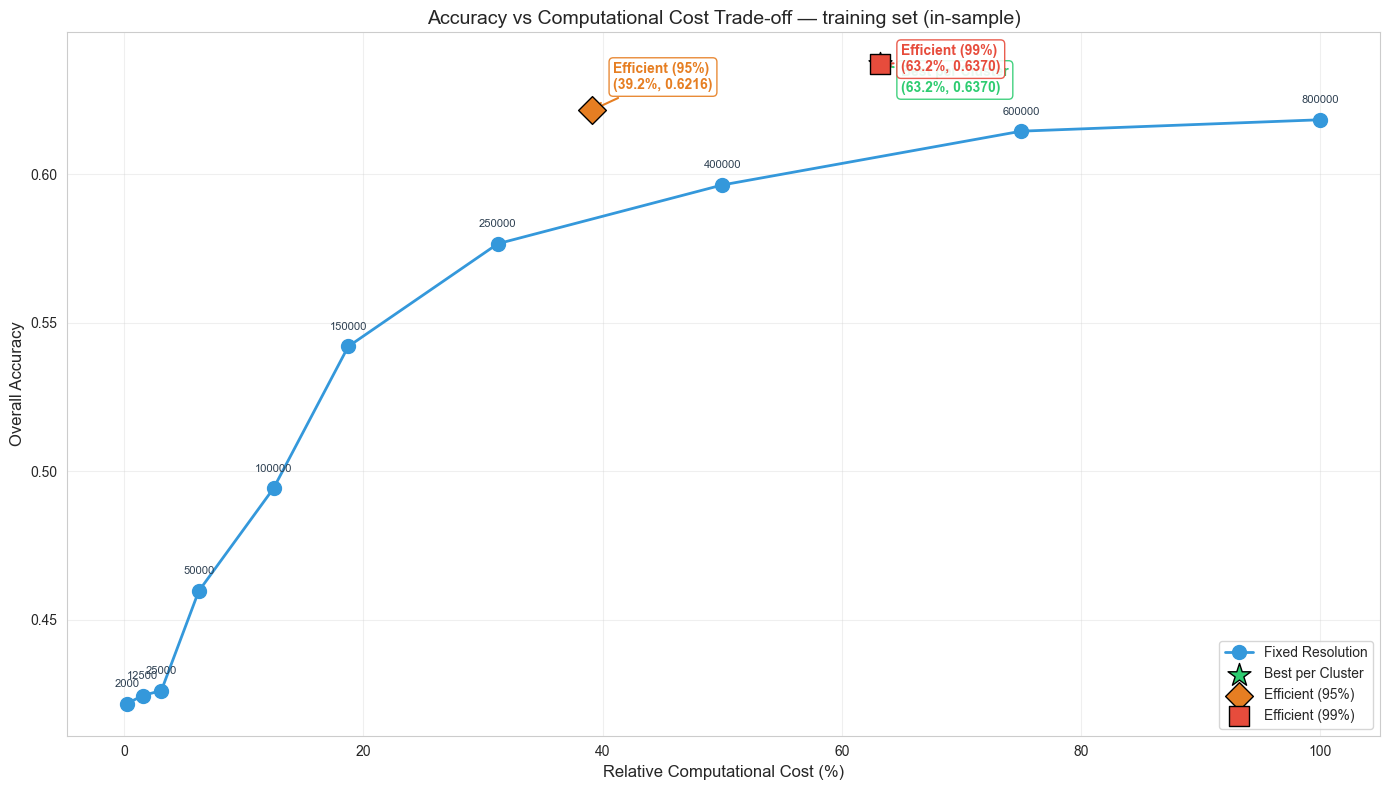

In [18]:
# Accuracy vs Computational Cost Trade-off
fig, ax = plt.subplots(figsize=(14, 8))

# Fixed resolution curve
ax.plot(df_fixed['cost_pct'], df_fixed['accuracy'], 'o-', color='#3498db',
        markersize=10, linewidth=2, label='Fixed Resolution', zorder=3)

for _, r in df_fixed.iterrows():
    ax.annotate(r['strategy'].replace('All at ', ''),
                (r['cost_pct'], r['accuracy']),
                textcoords='offset points', xytext=(0, 12), ha='center', fontsize=8, color='#2c3e50')

# Cluster-based strategies with prominent annotations
markers = {'Best per Cluster': ('*', '#2ecc71', 300), 
           'Efficient (95%)': ('D', '#e67e22', 200), 
           'Efficient (99%)': ('s', '#e74c3c', 200)}

for _, r in df_cluster_strat.iterrows():
    marker, color, size = markers[r['strategy']]
    ax.scatter(r['cost_pct'], r['accuracy'], marker=marker, c=color,
               s=size, zorder=5, edgecolors='black', linewidth=1, label=r['strategy'])

    # Annotate with visible (x, y) values
    ax.annotate(
        f"{r['strategy']}\n({r['cost_pct']:.1f}%, {r['accuracy']:.4f})",
        (r['cost_pct'], r['accuracy']),
        textcoords='offset points',
        xytext=(15, -20) if 'Best' in r['strategy'] else (15, 15) if '95' in r['strategy'] else (15, -5),
        fontsize=10, fontweight='bold', color=color,
        arrowprops=dict(arrowstyle='->', color=color, lw=1.5),
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=color, alpha=0.9)
    )

ax.set_xlabel('Relative Computational Cost (%)', fontsize=12)
ax.set_ylabel('Overall Accuracy', fontsize=12)
ax.set_title('Accuracy vs Computational Cost Trade-off — training set (in-sample)', fontsize=14)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 7. K-selection diagnostics (reporting only)

Nothing below changes the model. The pipeline above still selects K by silhouette over
`MIN_K..MAX_K` and ships K=30 — this section exists to document how well that choice
holds up, because the original search stopped at exactly its own ceiling.

Three questions are asked:

1. **Does silhouette keep rising past MAX_K?** If so, K=30 is a boundary artefact
   rather than an optimum.
2. **Do other internal criteria agree?** Calinski-Harabasz and Davies-Bouldin should
   roughly agree with silhouette when genuine cluster structure exists.
3. **Which K actually predicts the required resolution best?** Internal metrics score
   cluster *geometry*, not usefulness. This is measured by 5-fold cross-validation
   **inside the training split** — the held-out test rows are never touched here.

The task criterion is **lift**: strategy accuracy minus what a *fixed* resolution would
deliver **at the same cost**, interpolating the fixed-resolution curve. That is the
bar that matters, because beating "always 800000" while spending less is trivially
achievable by just picking a cheaper fixed resolution. Positive lift means adaptive
routing sits above the fixed-resolution frontier; negative means it sits below.

In [19]:
# ── Diagnostics configuration ────────────────────────────────────────────────
# Results are cached to CSV; set RECOMPUTE = True to regenerate (~18 min on CPU).
RECOMPUTE = False

DIAG_INTERNAL  = str(PROJECT_ROOT / 'clustering/training/results/k_diag_internal.csv')
DIAG_CV        = str(PROJECT_ROOT / 'clustering/training/results/k_diag_cv.csv')
DIAG_STABILITY = str(PROJECT_ROOT / 'clustering/training/results/k_diag_stability.csv')

DIAG_N_INIT = 5      # cheaper than the production fit's n_init=10; diagnostics only

# Grids (kept explicit so a recompute reproduces the committed CSVs)
KS_INTERNAL  = list(range(2, 51)) + list(range(52, 101, 2)) + list(range(105, 201, 5))
KS_CV        = [2, 3, 5, 8, 10, 12, 15, 20, 25, 30, 35, 40, 50, 60, 80, 100, 130, 160, 200]
KS_STABILITY = [2, 3, 5, 10, 20, 30, 50]
STABILITY_SEEDS = list(range(8))

# Order training rows by doc_id so diagnostics are independent of the split's shuffle
_order = np.argsort(df_train['doc_id'].values)
E_diag = embeddings[_order]
S_diag = df_train[RESOLUTIONS].values[_order].astype(float)   # (n, 10) binary correctness
RV = np.array([int(r) for r in RESOLUTIONS])
MAXR_DIAG = RV.max()
FIXED_ACC = S_diag.mean(axis=0)
FIXED_COST = RV / MAXR_DIAG * 100

print(f'Diagnostics on {len(E_diag)} training rows  ·  RECOMPUTE = {RECOMPUTE}')

Diagnostics on 1821 training rows  ·  RECOMPUTE = False


In [20]:
# ── Helpers shared by the diagnostic sweeps ──────────────────────────────────
from sklearn.model_selection import KFold
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score
from sklearn.metrics.pairwise import euclidean_distances


def _derive_mapping(scores_sub, labels_sub, k):
    """cluster -> resolution index, using the same rules as section 5."""
    best, eff95 = np.zeros(k, int), np.zeros(k, int)
    for c in range(k):
        m = labels_sub == c
        if not m.any():
            best[c] = eff95[c] = len(RESOLUTIONS) - 1
            continue
        acc = scores_sub[m].mean(axis=0)
        b = int(acc.argmax())
        best[c] = b
        hit = np.flatnonzero(acc >= acc[b] * 0.95)   # ascending -> first hit is cheapest
        eff95[c] = int(hit[0]) if len(hit) else b
    return best, eff95


def _lift(acc, cost_pct):
    """Accuracy above the fixed-resolution curve at equal cost (linear interpolation)."""
    if cost_pct <= FIXED_COST[0]:
        return acc - FIXED_ACC[0]
    if cost_pct >= FIXED_COST[-1]:
        return acc - FIXED_ACC[-1]
    j = np.searchsorted(FIXED_COST, cost_pct)
    w = (cost_pct - FIXED_COST[j - 1]) / (FIXED_COST[j] - FIXED_COST[j - 1])
    return acc - (FIXED_ACC[j - 1] * (1 - w) + FIXED_ACC[j] * w)


def _oof(k, seed):
    """Out-of-fold accuracy/cost/lift for a given K, pooling all 5 validation folds."""
    n = len(E_diag)
    idx = {'best': np.zeros(n, int), 'eff95': np.zeros(n, int)}
    for tr_i, va_i in KFold(n_splits=5, shuffle=True, random_state=seed).split(E_diag):
        km = KMeans(n_clusters=k, random_state=seed, n_init=DIAG_N_INIT).fit(E_diag[tr_i])
        best, eff95 = _derive_mapping(S_diag[tr_i], km.labels_, k)
        pred = km.predict(E_diag[va_i])
        idx['best'][va_i], idx['eff95'][va_i] = best[pred], eff95[pred]
    out = {}
    for name, ix in idx.items():
        acc = S_diag[np.arange(n), ix].mean()
        cost = RV[ix].mean() / MAXR_DIAG * 100
        out[name] = (acc, cost, _lift(acc, cost))
    return out

In [21]:
# ── Q1/Q2 · Internal criteria across a much wider K range ────────────────────
if RECOMPUTE:
    DIST = euclidean_distances(E_diag).astype(np.float32)   # once, not per K
    rows = []
    for k in KS_INTERNAL:
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=DIAG_N_INIT).fit(E_diag)
        cnt = np.bincount(km.labels_, minlength=k)
        rows.append({'k': k,
                     'silhouette': silhouette_score(DIST, km.labels_, metric='precomputed'),
                     'calinski_harabasz': calinski_harabasz_score(E_diag, km.labels_),
                     'davies_bouldin': davies_bouldin_score(E_diag, km.labels_),
                     'inertia': km.inertia_,
                     'min_cluster_n': int(cnt.min()),
                     'median_cluster_n': float(np.median(cnt))})
    df_internal = pd.DataFrame(rows)
    df_internal.to_csv(DIAG_INTERNAL, index=False)
else:
    df_internal = pd.read_csv(DIAG_INTERNAL)

df_internal = df_internal.sort_values('k').reset_index(drop=True)

print(f'Swept K = {df_internal.k.min()}..{df_internal.k.max()}  ({len(df_internal)} values)')
print(f"  silhouette        max at K={df_internal.loc[df_internal.silhouette.idxmax(), 'k']:.0f}"
      f"  ({df_internal.silhouette.max():.4f})")
print(f"  calinski_harabasz max at K={df_internal.loc[df_internal.calinski_harabasz.idxmax(), 'k']:.0f}"
      f"  ({df_internal.calinski_harabasz.max():.1f})")
print(f"  davies_bouldin    min at K={df_internal.loc[df_internal.davies_bouldin.idxmin(), 'k']:.0f}"
      f"  ({df_internal.davies_bouldin.min():.4f})")
_win = df_internal[(df_internal.k >= MIN_K) & (df_internal.k <= MAX_K)]
print(f'\n  within the production window {MIN_K}..{MAX_K}: silhouette max at '
      f"K={_win.loc[_win.silhouette.idxmax(), 'k']:.0f}  ({_win.silhouette.max():.4f})")

display(df_internal[df_internal.k.isin([2, 5, 10, 20, 30, 50, 90, 130, 165, 200])].round(4))

Swept K = 2..200  (94 values)
  silhouette        max at K=165  (0.0749)
  calinski_harabasz max at K=2  (80.9)
  davies_bouldin    min at K=190  (2.3349)

  within the production window 5..30: silhouette max at K=27  (0.0536)


,k,silhouette,calinski_harabasz,davies_bouldin,inertia,min_cluster_n,median_cluster_n
0,2,0.0354,80.9486,4.1240,1534.5801,496,910.5
3,5,0.0389,45.5604,4.7721,1456.6882,269,369.0
8,10,0.0364,31.3678,4.3319,1386.7035,143,180.0
18,20,0.0465,23.1012,3.6063,1288.7816,28,85.5
28,30,0.0529,19.2397,3.3535,1222.1384,22,58.5
48,50,0.0605,14.6007,3.1976,1141.6683,17,33.5
68,90,0.0667,10.6405,2.8539,1036.0583,3,19.0
79,130,0.0684,8.5814,2.6353,968.7136,3,12.5
86,165,0.0749,7.5954,2.4466,914.7743,2,10.0
93,200,0.0693,6.8442,2.3535,871.0206,2,8.0


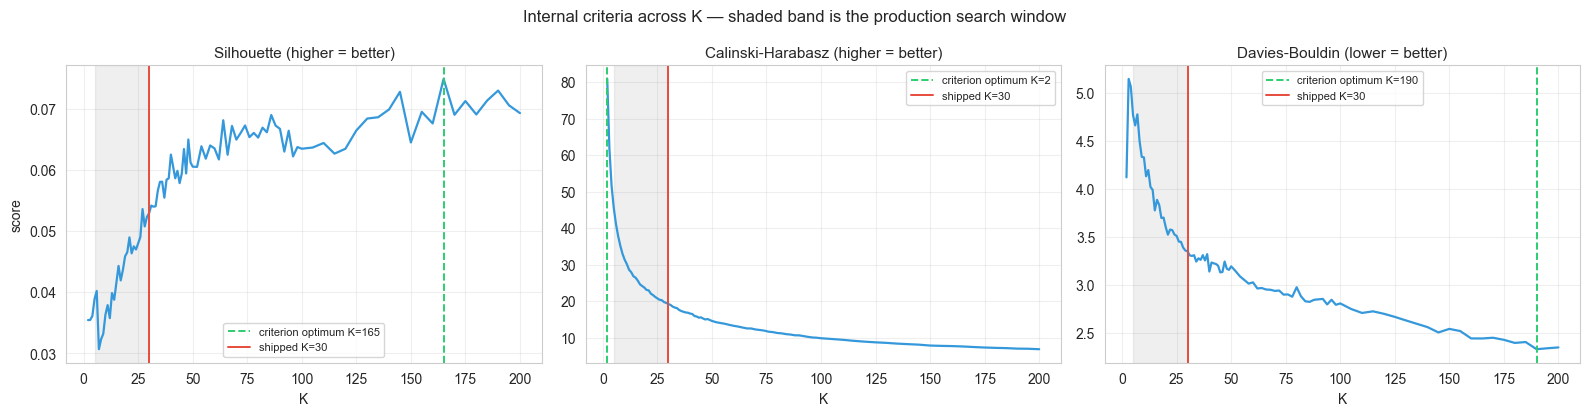

Silhouette never exceeds 0.075 at any K. On a -1..1 scale, values below ~0.25 indicate essentially no cluster structure:
the embeddings form one continuous cloud that KMeans is partitioning arbitrarily.


In [22]:
# ── Internal criteria vs K ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

for ax, col, label, best_fn in [
    (axes[0], 'silhouette',        'Silhouette (higher = better)',        'max'),
    (axes[1], 'calinski_harabasz', 'Calinski-Harabasz (higher = better)', 'max'),
    (axes[2], 'davies_bouldin',    'Davies-Bouldin (lower = better)',     'min'),
]:
    ax.plot(df_internal['k'], df_internal[col], '-', color='#3498db', lw=1.6)
    kbest = df_internal.loc[df_internal[col].idxmax() if best_fn == 'max'
                            else df_internal[col].idxmin(), 'k']
    ax.axvline(kbest, color='#2ecc71', ls='--', lw=1.4, label=f'criterion optimum K={kbest:.0f}')
    ax.axvline(OPTIMAL_K, color='#e74c3c', ls='-', lw=1.4, label=f'shipped K={OPTIMAL_K}')
    ax.axvspan(MIN_K, MAX_K, color='grey', alpha=0.12)
    ax.set_xlabel('K'); ax.set_title(label, fontsize=11)
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

axes[0].set_ylabel('score')
fig.suptitle('Internal criteria across K — shaded band is the production search window',
             fontsize=12)
plt.tight_layout()
plt.show()

print('Silhouette never exceeds '
      f'{df_internal.silhouette.max():.3f} at any K. On a -1..1 scale, values below ~0.25 '
      'indicate essentially no cluster structure:\nthe embeddings form one continuous '
      'cloud that KMeans is partitioning arbitrarily.')

In [23]:
# ── Q3 · Which K actually predicts the required resolution? ──────────────────
if RECOMPUTE:
    rows = []
    for k in KS_CV:
        o = _oof(k, RANDOM_STATE)
        rows.append({'k': k,
                     'best_acc': o['best'][0],  'best_cost': o['best'][1],  'best_lift': o['best'][2],
                     'eff95_acc': o['eff95'][0], 'eff95_cost': o['eff95'][1], 'eff95_lift': o['eff95'][2]})
    df_cv = pd.DataFrame(rows)
    df_cv.to_csv(DIAG_CV, index=False)
else:
    df_cv = pd.read_csv(DIAG_CV)

df_cv = df_cv.sort_values('k').reset_index(drop=True)

print('OUT-OF-FOLD PERFORMANCE (5-fold CV inside the training split)')
print('=' * 78)
print('lift > 0  ->  above the fixed-resolution curve at equal cost')
print(f"\npositive best_lift at {(df_cv.best_lift > 0).sum()} of {len(df_cv)} K values"
      f"  ·  max at K={df_cv.loc[df_cv.best_lift.idxmax(), 'k']:.0f}"
      f" ({df_cv.best_lift.max():+.4f})")
print(f"lift at the shipped K={OPTIMAL_K}: "
      f"{df_cv.loc[df_cv.k == OPTIMAL_K, 'best_lift'].iloc[0]:+.4f}\n")
display(df_cv.round(4))

OUT-OF-FOLD PERFORMANCE (5-fold CV inside the training split)
lift > 0  ->  above the fixed-resolution curve at equal cost

positive best_lift at 2 of 19 K values  ·  max at K=2 (+0.0055)
lift at the shipped K=30: -0.0147



,k,best_acc,best_cost,best_lift,eff95_acc,eff95_cost,eff95_lift
0,2,0.6211,81.8232,0.0055,0.5903,52.7526,-0.0080
1,3,0.6189,85.5711,0.0028,0.6030,48.6992,0.0080
2,5,0.6150,79.6129,-0.0002,0.5920,53.8406,-0.0072
3,8,0.6068,74.8593,-0.0076,0.5986,48.9463,0.0033
4,10,0.6046,71.0221,-0.0070,0.5953,50.1944,-0.0012
5,12,0.6074,68.4533,-0.0024,0.5936,50.6026,-0.0032
6,15,0.6101,70.5420,-0.0012,0.5947,47.6107,0.0009
7,20,0.6063,68.6785,-0.0037,0.5881,49.3553,-0.0076
8,25,0.5986,67.2556,-0.0103,0.5903,51.1552,-0.0069
9,30,0.5898,61.2020,-0.0147,0.5766,45.9339,-0.0155


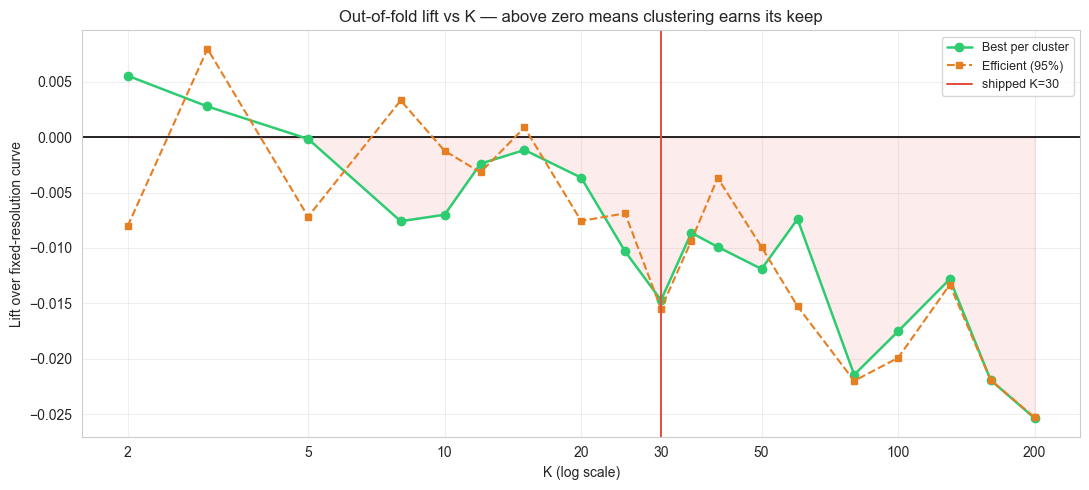

In [24]:
# ── Lift vs K ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))

ax.axhline(0, color='black', lw=1.2)
ax.plot(df_cv['k'], df_cv['best_lift'], 'o-', color='#2ecc71', lw=1.8, ms=6,
        label='Best per cluster')
ax.plot(df_cv['k'], df_cv['eff95_lift'], 's--', color='#e67e22', lw=1.5, ms=5,
        label='Efficient (95%)')
ax.axvline(OPTIMAL_K, color='#e74c3c', lw=1.4, label=f'shipped K={OPTIMAL_K}')

ax.fill_between(df_cv['k'], 0, df_cv['best_lift'].clip(upper=0), color='#e74c3c', alpha=0.10)
ax.set_xscale('log')
ax.set_xticks([2, 5, 10, 20, 30, 50, 100, 200])
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax.set_xlabel('K (log scale)'); ax.set_ylabel('Lift over fixed-resolution curve')
ax.set_title('Out-of-fold lift vs K — above zero means clustering earns its keep',
             fontsize=12)
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [25]:
# ── Is the K ranking stable, or is it noise? ─────────────────────────────────
if RECOMPUTE:
    rows = []
    for seed in STABILITY_SEEDS:
        for k in KS_STABILITY:
            acc, cost, lf = _oof(k, seed)['best']
            rows.append({'k': k, 'seed': seed, 'best_acc': acc, 'best_cost': cost,
                         'best_lift': lf})
    df_stab = pd.DataFrame(rows)
    df_stab.to_csv(DIAG_STABILITY, index=False)
else:
    df_stab = pd.read_csv(DIAG_STABILITY)

g = (df_stab.groupby('k')['best_lift']
     .agg(mean_lift='mean', sd_lift='std', min_lift='min', max_lift='max', n_seeds='count'))

across = g['mean_lift'].max() - g['mean_lift'].min()
within = g['sd_lift'].mean()

print(f'STABILITY — same K re-measured over {df_stab.seed.nunique()} independent CV partitions')
print('=' * 78)
display(g.round(4))
print(f'spread ACROSS K (range of mean lift): {across:.4f}')
print(f'typical spread WITHIN one K (mean sd): {within:.4f}')

wins = df_stab.loc[df_stab.groupby('seed')['best_lift'].idxmax()].sort_values('seed')
print(f"\nbest K per partition: {wins['k'].tolist()}")
print('If the winning K changes from partition to partition, K is not identifiable '
      'from this data\nand no single value should be claimed as optimal.')

STABILITY — same K re-measured over 8 independent CV partitions


,mean_lift,sd_lift,min_lift,max_lift,n_seeds
k,,,,,
2,0.0039,0.0021,0.0011,0.0056,8
3,-0.0018,0.0027,-0.0051,0.0019,8
5,-0.0009,0.0028,-0.0061,0.0021,8
10,-0.0052,0.0037,-0.0093,0.0005,8
20,-0.0059,0.0038,-0.0136,-0.0010,8
30,-0.0065,0.0055,-0.0154,0.0030,8
50,-0.0044,0.0079,-0.0134,0.0084,8


spread ACROSS K (range of mean lift): 0.0104
typical spread WITHIN one K (mean sd): 0.0041

best K per partition: [30, 50, 2, 2, 2, 2, 2, 2]
If the winning K changes from partition to partition, K is not identifiable from this data
and no single value should be claimed as optimal.


### Findings

**1. K=30 is a boundary artefact.** Silhouette keeps climbing past `MAX_K`, peaking
around K=165. The original search returned the edge of its own window, not an optimum.

**2. There is no natural K, because there is barely any cluster structure.** Silhouette
never exceeds ~0.075 at any K between 2 and 200 — an order of magnitude below what
counts as meaningful structure. The three internal criteria disagree completely
(silhouette → ~165, Calinski-Harabasz → 2, Davies-Bouldin → ~190), which is the
signature of partitioning a continuous cloud rather than finding real groups.

**3. On the task that matters, more clusters is strictly worse.** Out-of-fold lift is
positive at only 2 of 19 K values (K=2 and K=3, both marginal) and degrades
monotonically as K grows. At the shipped K=30 the strategy lands roughly 1.5pp *below*
the fixed-resolution curve at equal cost. The mechanism is straightforward: larger K
means fewer questions per cluster, and the per-cluster `argmax` over 10 resolutions
becomes noise-fitting.

**4. Among K = 3…50 the ranking is not identifiable.** Re-measuring across 8 independent
CV partitions, the scatter within a single K (sd ≈ 0.004) is as large as the differences
between K values. Only K=2 is consistently positive (8/8 partitions), and a two-cluster
split is not meaningfully "adaptive resolution selection".

### What this means for the shipped model

K=30 is retained for continuity, but it should be reported as a **convention, not an
optimum** — it is neither the silhouette optimum over a wide range nor competitive on
out-of-fold lift. The accuracy-vs-cost gains shown in section 6 are in-sample; the
inference notebook's held-out comparison against fixed-800000 is not statistically
significant (McNemar p ≈ 0.65).

The bottleneck is not the value of K. It is that KMeans over `all-MiniLM-L6-v2`
embeddings of the question stem does not produce groups whose optimal resolution
differs reliably. Promising directions, in rough order of expected payoff: features
that mechanistically determine legibility (native image size, OCR text height as a
fraction of image height, high-frequency energy); predicting the minimum sufficient
resolution per question directly rather than routing through a cluster `argmax`, which
would use all training rows for one estimator instead of splitting them across 30 tiny
ones; and a richer text encoder.